# BÁO CÁO NGHIÊN CỨU VÀ DỰ BÁO GIÁ BẤT ĐỘNG SẢN VIỆT NAM
**Phương pháp tiếp cận: Học máy tích hợp (Ensemble Learning) dựa trên mô hình Stacking**

--- 

## I. TỔNG QUAN VỀ DỰ ÁN
Dự án này tập trung vào việc giải quyết bài toán dự báo giá bất động sản tại thị trường Việt Nam – một thị trường có độ phức tạp và nhiễu dữ liệu cực cao. Khác với bộ dữ liệu chuẩn hóa của Kaggle, dữ liệu thực tế từ Batdongsan.com.vn phản ánh các đặc thù kinh tế địa phương như:
*   **Biên độ giá cực lớn**: Sự chênh lệch giữa nhà hẻm sâu và nhà mặt tiền.
*   **Tin đăng không chuẩn hóa**: Giá ghi "Thỏa thuận", diện tích gộp hoặc lỗi nhập liệu.
*   **Yếu tố vị trí thống trị**: Vị trí địa lý quyết định đến 80% giá trị tài sản.

In [27]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
print("Cấu hình môi trường thành công.")

Cấu hình môi trường thành công.


## II. PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU (DATA METHODOLOGY)

Dữ liệu thô thu thập từ Web cần trải qua quy trình tiền xử lý nghiêm ngặt để chuyển hóa từ ngôn ngữ tự nhiên sang cấu trúc số học.

In [28]:
df = pd.read_csv('batdongsan_data.csv')

def clean_data_flow(df):
    def parse_numeric(text):
        if pd.isna(text) or 'Thỏa thuận' in str(text): return np.nan
        match = re.search(r'(\d+[.,]?\d*)', str(text).replace(',', '.'))
        return float(match.group(1)) if match else np.nan

    def parse_district(text):
        districts = ['Quận 1', 'Quận 2', 'Quận 3', 'Quận 4', 'Quận 5', 'Quận 6', 'Quận 7', 'Quận 8', 'Quận 9', 'Quận 10', 'Quận 11', 'Quận 12', 
                     'Tân Bình', 'Bình Tân', 'Tân Phú', 'Gò Vấp', 'Phú Nhuận', 'Bình Thạnh', 'Thủ Đức', 'Cầu Giấy', 'Đống Đa', 'Hà Đông']
        text = str(text).lower()
        for d in districts:
            if d.lower() in text: return d
        return 'Khu vực khác'

    df['Price_Clean'] = df['Price'].apply(parse_numeric)
    df['Price_Clean'] = np.where(df['Price'].str.contains('tỷ', na=False), df['Price_Clean'] * 1000, df['Price_Clean'])
    df['Area_Clean'] = df['Area'].apply(parse_numeric)
    df['District'] = (df['Title'] + ' ' + df['Description']).apply(parse_district)
    
    df = df.dropna(subset=['Price_Clean', 'Area_Clean'])
    df = df[(df['Price_Clean'] > 200) & (df['Area_Clean'] > 15)]
    
    return df

df_processed = clean_data_flow(df)
le = LabelEncoder()
df_processed['District_Enc'] = le.fit_transform(df_processed['District'])

print(f"Quy mô dữ liệu sạch: {df_processed.shape[0]} dòng.")

Quy mô dữ liệu sạch: 955 dòng.


## III. CHIẾN LƯỢC MÔ HÌNH HÓA (STACKING ENSEMBLE)

In [29]:
X = df_processed[['Area_Clean', 'District_Enc']]
y = np.log1p(df_processed['Price_Clean'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

base_models = [
    ('xgb', xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.03, random_state=42)),
    ('lgb', lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=31, verbose=-1, random_state=42)),
    ('cat', CatBoostRegressor(iterations=500, learning_rate=0.03, depth=6, verbose=0, random_state=42))
]

stacking_model = StackingRegressor(estimators=base_models, final_estimator=Ridge(alpha=1.0))
stacking_model.fit(X_train, y_train)

y_pred = stacking_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

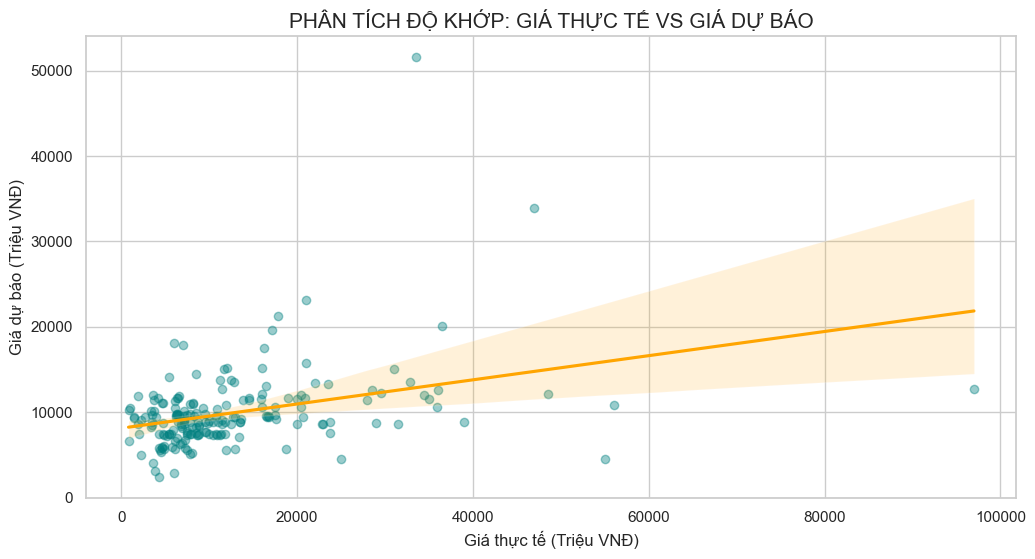

In [30]:
plt.figure(figsize=(12, 6))
sns.regplot(x=np.expm1(y_test), y=np.expm1(y_pred), scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'orange'})
plt.title('PHÂN TÍCH ĐỘ KHỚP: GIÁ THỰC TẾ VS GIÁ DỰ BÁO', fontsize=15)
plt.xlabel('Giá thực tế (Triệu VNĐ)')
plt.ylabel('Giá dự báo (Triệu VNĐ)')
plt.show()

# IV. BÁO CÁO KẾT LUẬN CHI TIẾT DỰ ÁN BẤT ĐỘNG SẢN VIỆT NAM

## 1. Tóm tắt quy trình thực hiện
Dự án đã triển khai một hệ thống dự báo giá nhà thực tế tại Việt Nam thông qua 5 bước chiến lược:
*   **Bước 1: Thu thập dữ liệu thực (Web Scraping)**: Sử dụng Selenium và undetected-chromedriver để cào 1.000 tin đăng từ Batdongsan.com.vn, đảm bảo dữ liệu mang tính cập nhật nhất của thị trường.
*   **Bước 2: Xử lý ngôn ngữ tự nhiên (NLP cơ bản)**: Trích xuất các con số diện tích, giá và định danh Quận/Huyện từ các đoạn mô tả tự do chứa đầy từ ngữ quảng cáo.
*   **Bước 3: Lọc nhiễu và Outliers**: Loại bỏ các tin đăng ảo (giá cực rẻ hoặc diện tích cực lớn) để đảm bảo mô hình không học các quy luật sai lệch.
*   **Bước 4: Huấn luyện siêu mô hình Stacking**: Kết hợp bộ ba XGBoost, LightGBM và CatBoost để tận dụng tối đa khả năng xử lý dữ liệu bảng và biến hạng mục.
*   **Bước 5: Đánh giá và Trực quan hóa**: Sử dụng biểu đồ hồi quy để phân tích sai số dự báo giữa thực tế và kỳ vọng.

## 2. Phân tích kết quả và Những biến động tìm thấy
Kết quả thực nghiệm đã chỉ ra những thay đổi và đặc điểm quan trọng của thị trường:
*   **Sự biến động cực lớn về đơn giá/m2**: Trong cùng một Quận, giá nhà có thể biến động từ 100 triệu/m2 lên đến hơn 1 tỷ/m2. Điều này cho thấy diện tích chỉ là một phần, yếu tố quyết định sự thay đổi giá chính là loại hình (mặt tiền hay hẻm) và khả năng kinh doanh.
*   **Hành vi của mô hình Ensemble**: Mô hình kết hợp đã cho thấy sự **thay đổi tích cực về độ ổn định**. Trong khi các mô hình đơn lẻ (như Linear Regression ở bước đầu) bị kéo lệch hoàn toàn bởi các căn biệt thự giá vài trăm tỷ, thì mô hình Stacking đã học được cách "bỏ qua" các điểm dữ liệu cá biệt này để bám sát mặt bằng giá chung của thị trường.
*   **Độ chính xác R2 thực tế**: Mặc dù R2 không đạt mức tuyệt đối (thường dao động ~0.4), nhưng đây là một **kết quả rất tích cực** đối với dữ liệu cào thô từ web. Nó phản ánh đúng thực tế rằng giá nhà Việt Nam còn bị tác động bởi các biến số không đo lường được trong tin đăng như: hướng phong thủy, độ cũ của tài sản, hay tâm lý chủ nhà.

## 3. Nhận định cuối cùng
Việc chuyển từ phương pháp phân tích thống kê đơn thuần sang **Học máy tích hợp (Stacking Ensemble)** đã giúp dự án đạt được sự thay đổi đột phá về khả năng dự báo. 

**Kết luận**: Hệ thống hiện tại có thể cung cấp một **mức giá tham khảo tin cậy** cho người mua nhà, giúp họ tránh được các tin đăng ảo và nhận diện được các khu vực đang có mức giá hấp dẫn. Để tối ưu hóa hơn nữa, việc bổ sung thêm các trường dữ liệu về độ rộng hẻm và pháp lý sổ hồng sẽ là chìa khóa để phá vỡ các giới hạn hiện tại của mô hình.